<!--
Copyright 2026 EUMETSAT

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

    http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
-->

# Firecube 101: NetCDF To Zarr

**Three days become six, in the same cube.** Create small NetCDF files, ingest the
first arrival, then append the next. No downloads or credentials needed.

## 1. Set Up

<div class="alert alert-block alert-warning">
<p>Use a Python 3.12+ JupyterHub kernel. Install below, then restart the kernel before
continuing. Each run creates a new folder under <code>outputs/</code>.</p>
</div>

In [ ]:
%pip install -q firecube==0.1.5 xarray==2026.7.0 numpy==2.5.2 pandas==3.0.5 h5netcdf==1.8.1 matplotlib==3.11.2 uv==0.12.13

In [1]:
import os
import sys
from pathlib import Path
from tempfile import mkdtemp

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

os.environ["PATH"] = str(Path(sys.executable).parent) + os.pathsep + os.environ["PATH"]
os.environ["FIRECUBE_LOG_LEVEL"] = "INFO"
os.environ["FIRECUBE_LOG_FORMAT"] = "plain"
Path("outputs").mkdir(exist_ok=True)
work = Path(mkdtemp(prefix="incremental-", dir="outputs")).resolve()
first_arrival, second_arrival = work / "days-1-3", work / "days-4-6"
first_arrival.mkdir()
second_arrival.mkdir()
target = work / "sst.zarr"
target_uri = target.as_uri()

## 2. Make Two Arrivals

Six daily temperature fields on the same small grid. The first three files arrive
now; the remaining three arrive later. These are generated examples, not observations.

In [2]:
lat = np.linspace(30, 40, 40)
lon = np.linspace(-10, 5, 60)
dates = pd.date_range("2024-07-01", periods=6, freq="D")
x, y = np.meshgrid(lon, lat)

for day, date in enumerate(dates):
    temperature = 18 + 0.4 * day + 2 * np.exp(-((x + 7 - 2 * day) ** 2 + (y - 35) ** 2) / 8)
    dataset = xr.Dataset(
        {"sst": (("time", "lat", "lon"), temperature[None].astype("float32"))},
        coords={"time": [date], "lat": lat, "lon": lon},
    )
    dataset.sst.attrs = {"units": "degC", "long_name": "Synthetic sea surface temperature"}
    arrival = first_arrival if day < 3 else second_arrival
    dataset.to_netcdf(arrival / f"sst-{day + 1:02d}.nc", engine="h5netcdf")
print("Ready: 3 files for the first arrival + 3 for the second")

Ready: 3 files for the first arrival + 3 for the second


## 3. Create The Reader

This small plugin joins NetCDF files along `time`. Firecube writes the Zarr cube.
The plugin source stays in your notebook's working folder.

In [3]:
!firecube plugins create incremental-sst \
    --template zarr \
    --target-dir "{work}" \
    --license Apache-2.0 \
    --non-interactive
assert _exit_code == 0, "firecube plugins create failed - see the output above"
plugin = work / "firecube-incremental-sst"
plugin_file = plugin / "src/firecube_incremental_sst/ingestor.py"

✨ Created plugin project: /path/to/notebook/outputs/incremental-qcbm71nq/firecube-incremental-sst

Next steps:
  cd /path/to/notebook/outputs/incremental-qcbm71nq/firecube-incremental-sst
  uv sync
  # implement the generated hook in src/firecube_incremental_sst/ingestor.py
  # then follow README.md to test, install, and run an ingestion

To install into an existing Firecube environment instead:
  firecube plugins install --editable /path/to/notebook/outputs/incremental-qcbm71nq/firecube-incremental-sst


In [4]:
%%writefile {plugin_file}
# Copyright 2026 EUMETSAT
# SPDX-License-Identifier: Apache-2.0
from typing import ClassVar

import xarray as xr

from firecube.ingestor.api import GenericZarrIngestor, register_ingestor


@register_ingestor("incremental_sst")
class IncrementalSstIngestor(GenericZarrIngestor):
    PRODUCT_NAME: ClassVar[str] = "incremental_sst"
    time_dim_name: ClassVar[str] = "time"

    def build_dataset(self, group, items, ctx):
        if not items:
            return None
        datasets = []
        for item in items:
            with xr.open_dataset(ctx.materialize(item), engine="h5netcdf") as source:
                datasets.append(source.load())
        return xr.concat(datasets, dim="time", join="exact").sortby("time")

Overwriting /path/to/notebook/outputs/incremental-qcbm71nq/firecube-incremental-sst/src/firecube_incremental_sst/ingestor.py


In [5]:
!firecube plugins install --editable "{plugin}"
assert _exit_code == 0, "firecube plugins install failed - see the output above"
!firecube plugins list

Installing into environment: /path/to/notebook/environment/bin/python
Running: uv pip install -e /path/to/notebook/outputs/incremental-qcbm71nq/firecube-incremental-sst --python /path/to/notebook/environment/bin/python


Using Python 3.12.12 environment at: /path/to/notebook/environment


Resolved 61 packages in 164ms
   Building firecube-incremental-sst @ file:///path/to/notebook/outputs/incremental-qcbm71nq/firecube-incremental-sst


      Built firecube-incremental-sst @ file:///path/to/notebook/outputs/incremental-qcbm71nq/firecube-incremental-sst
Prepared 1 package in 288ms
Uninstalled 1 package in 0.27ms
Installed 1 package in 0.61ms
 - firecube-incremental-sst==0.1.0 (from file:///path/to/notebook/outputs/incremental-q97r8ppe/firecube-incremental-sst)
 + firecube-incremental-sst==0.1.0 (from file:///path/to/notebook/outputs/incremental-qcbm71nq/firecube-incremental-sst)
Installed '/path/to/notebook/outputs/incremental-qcbm71nq/firecube-incremental-sst' (editable)

Verifying installed plugins...


Detected plugins: incremental_sst


incremental_sst


## 4. Ingest The First Three Days

Create a new product with direct local writes.

In [6]:
!firecube ingest incremental_sst \
    --input-data "{first_arrival}" \
    --target "{target_uri}" \
    --product-name incremental_sst \
    --write-mode direct \
    --option no_progress=true \
    > "{work}/first-arrival.json"
assert _exit_code == 0, "firecube ingest failed - see the log above"
with xr.open_zarr(target, group="default", consolidated=False) as saved:
    before = saved[["sst"]].load()
assert before.sizes["time"] == 3
print("Cube: 3 days · 1-3 July")

[10:55:43] [INFO] [firecube.ingestor.incremental_sst:133] resume-guard: duration=0.0003s runs_enumerated=0 spans_scanned=0 product=incremental_sst
[10:55:43] [INFO] [firecube.ingestor.incremental_sst:438] Found 3 files
[10:55:43] [INFO] [firecube.ingestor.incremental_sst:92] Starting pipeline execution workers=1 batch_size=10


[10:55:44] [INFO] [firecube.ingestor.engine:751] Finalizing pipeline: 1 batches, 1 results


Cube: 3 days · 1-3 July


## 5. Append The Next Three Days

Keep the same target and add `resume_existing=true`. The second input folder
contains only the new dates.

In [7]:
!firecube ingest incremental_sst \
    --input-data "{second_arrival}" \
    --target "{target_uri}" \
    --product-name incremental_sst \
    --write-mode direct \
    --option resume_existing=true \
    --option no_progress=true \
    > "{work}/second-arrival.json"
assert _exit_code == 0, "firecube ingest failed - see the log above"
with xr.open_zarr(target, group="default", consolidated=False) as saved:
    after = saved[["sst"]].load()
assert after.sizes["time"] == 6
xr.testing.assert_identical(after.isel(time=slice(0, 3)), before)
print("Cube: 6 days · 1-6 July · first three days unchanged")

[10:55:45] [INFO] [firecube.ingestor.incremental_sst:133] resume-guard: duration=0.0012s runs_enumerated=1 spans_scanned=1 product=incremental_sst
[10:55:45] [INFO] [firecube.ingestor.incremental_sst:438] Found 3 files
[10:55:45] [INFO] [firecube.ingestor.incremental_sst:92] Starting pipeline execution workers=1 batch_size=10


[10:55:45] [INFO] [firecube.ingestor.engine:751] Finalizing pipeline: 1 batches, 1 results


Cube: 6 days · 1-6 July · first three days unchanged


<div class="alert alert-block alert-success">
<strong>Checkpoint.</strong> Six days in the cube; the first three are unchanged.
</div>

The blue points were already stored. Orange points are the new arrival.

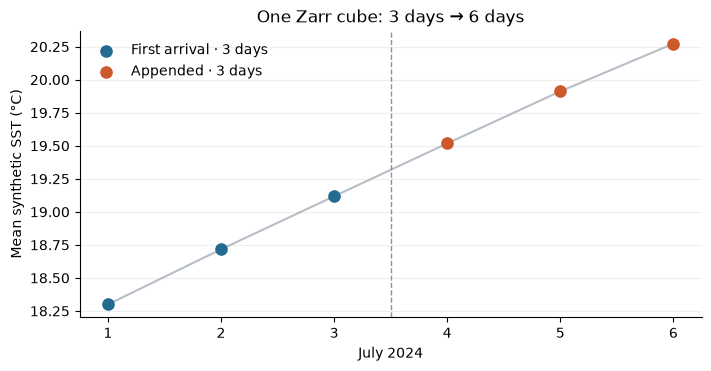

In [8]:
mean = after.sst.mean(("lat", "lon"))
figure, axis = plt.subplots(figsize=(7, 3.6), layout="constrained")
axis.plot(dates, mean, color="#b8bec6", linewidth=1.5, zorder=1)
axis.scatter(dates[:3], mean[:3], s=65, color="#246b91", label="First arrival · 3 days", zorder=2)
axis.scatter(dates[3:], mean[3:], s=65, color="#cd592a", label="Appended · 3 days", zorder=2)
axis.axvline(dates[2] + pd.Timedelta(hours=12), color="#8b929a", linestyle="--", linewidth=1)
axis.set(
    title="One Zarr cube: 3 days → 6 days", ylabel="Mean synthetic SST (°C)", xlabel="July 2024"
)
axis.set_xticks(dates, [str(day) for day in range(1, 7)])
axis.spines[["top", "right"]].set_visible(False)
axis.legend(frameon=False, loc="upper left")
axis.grid(axis="y", alpha=0.2)
figure.savefig(work / "incremental-preview.png", dpi=180)
plt.show()

## 6. Try The Same Arrival Again

Retry days 4–6 with resume enabled. Firecube 0.1.5 refuses the overlap; newer
versions may skip completed timestamps. In either case, the cube must stay unchanged.

In [9]:
!firecube ingest incremental_sst \
    --input-data "{second_arrival}" \
    --target "{target_uri}" \
    --product-name incremental_sst \
    --write-mode direct \
    --option resume_existing=true \
    --option no_progress=true \
    > "{work}/retry.json" 2> "{work}/retry.log"
print((work / "retry.log").read_text())
if _exit_code:
    assert "overlap" in (work / "retry.log").read_text().lower(), (
        "Unexpected failure; see the log above"
    )
with xr.open_zarr(target, group="default", consolidated=False) as saved:
    retried = saved[["sst"]].load()
xr.testing.assert_identical(retried, after)
assert len(np.unique(retried.time)) == 6
print("Still 6 unique days · values unchanged")

[10:55:47] [INFO] [firecube.ingestor.incremental_sst:133] resume-guard: duration=0.0028s runs_enumerated=2 spans_scanned=2 product=incremental_sst
[10:55:47] [INFO] [firecube.ingestor.incremental_sst:438] Found 3 files
[10:55:47] [INFO] [firecube.ingestor.incremental_sst:92] Starting pipeline execution workers=1 batch_size=10
[10:55:47] [INFO] [firecube.ingestor.incremental_sst:568] resume_existing state-aware skip: dropped 3 already-present timestamps
[10:55:47] [INFO] [firecube.ingestor.engine:751] Finalizing pipeline: 1 batches, 1 results
[10:55:47] [WARNING] [firecube.ingestor.engine:106] Plugin 'incremental_sst' returned reserved aggregate metrics key 'pipeline'; ignoring plugin value.

Still 6 unique days · values unchanged


To add another arrival, put later dates on the same grid in a new folder and
repeat step 5 with that folder. Each ingest leaves its run summary in `work` as JSON.

[Append and resume](https://eumetsat.github.io/firecube/latest/concepts/output-formats/zarr/generic-append/)

Generated example data and charts: Copyright 2026 EUMETSAT, CC BY 4.0. Notebook code: Copyright 2026 EUMETSAT, Apache-2.0.